# Growth-Geometry Split notebook for $\Omega_m$

This notebook works with the `cloelib` branch `346-omegam-split-ODE-growth-rescale-power-spectrum` . The plots show the validation with the CosmoSIS implementation but work only if one has the pickle outputs. That is why they are commented out.

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
from scipy import interpolate
from cloelib.cosmology.class_cosmology import CLASSBackground
from cloelib.cosmology.derived_cosmology import growth_function_ODE
from cloelib.cosmology.split_cosmology import (
    SplitLinearPerturbations, SplitNonLinearPerturbations
)

2026-01-29 16:39:28.026267: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769701168.062204    7438 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769701168.073055    7438 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769701168.128887    7438 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769701168.128918    7438 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769701168.128920    7438 computation_placer.cc:177] computation placer alr

/home/fkeil/miniforge3/envs/cloe-org/lib/python3.12/site-packages/HMcode2020Emu
Loading linear emulator...


2026-01-29 16:39:30.903948: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Linear emulator loaded in memory.
Loading nonlinear emulator...
Non-linear emulator loaded in memory.
Loading linear emulator...
Baryonic boost emulator loaded in memory.
Loading sigma8 emulator...
Linear emulator loaded in memory.


In [2]:
# # Cosmology parameters

H0 = 69.0
h = H0 / 100.0
Omega_b0 = 0.048
Omega_m = 0.3
Omega_cdm0 = Omega_m - Omega_b0
Omega_k0 = 0.0
w = -1.0
wa = 0.0
ns = 0.97
As = 2.19e-9
gamma_MG = 0.0
mnu = 0.0773 # Cannot be zero for HMCodeEmu
N_ur = 2.0308
N_mnu = 1

z = np.linspace(0, 3, 100)
# Compute the background with CLASS
class_instance_3 = CLASSBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    mnu=mnu,
    N_mnu=N_mnu,
)

## Differential Equation for the Growth G(z)

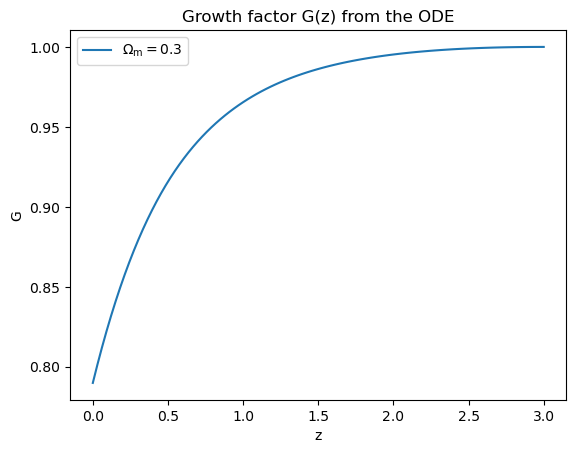

In [5]:
# Test the differential equation for the growth G(z)
g_z_3 = growth_function_ODE(class_instance_3, z)
plt.plot(z, g_z_3, label=r"$\Omega_{\rm m}=0.3$")
plt.xlabel("z")
plt.ylabel("G")
plt.legend()
plt.title("Growth factor G(z) from the ODE")
plt.show()

## Rescaled Matter Power Spectrum
Plots show the CosmoSIS Validation where we implemented the growth-geometry split. This only works with the pickle files from CosmoSIS.

In [6]:
ks = np.logspace(np.log10(3e-4), np.log10(1e0), 200)

# Compute the split MPS for 5 combinations of values for Omega_m^geo and
# Omega_m^growth: here Omega_m^geo = 0.3, Omega_m^growth = 0.3

split_linear_3_3 = SplitLinearPerturbations(
    background=class_instance_3, omega_m_growth=0.3, redshifts=z)

split_nonlinear_3_3 = SplitNonLinearPerturbations(
    background=class_instance_3,
    linperturbations=split_linear_3_3,
    omega_m_growth=0.3,
    redshifts=z,
    )

nonlinear_pk_3_3 = split_nonlinear_3_3.matter_power_spectrum(z, ks)

# Omega_m^geo = 0.3, Omega_m^growth = 0.25

split_linear_3_25 = SplitLinearPerturbations(
    background=class_instance_3, omega_m_growth=0.25, redshifts=z)

split_nonlinear_3_25 = SplitNonLinearPerturbations(
    background=class_instance_3,
    linperturbations=split_linear_3_25,
    omega_m_growth=0.25,
    redshifts=z,
)

nonlinear_pk_3_25 = split_nonlinear_3_25.matter_power_spectrum(z, ks)

# Omega_m^geo = 0.3, Omega_m^growth = 0.35

split_linear_3_35 = SplitLinearPerturbations(
    background=class_instance_3, omega_m_growth=0.35, redshifts=z)

split_nonlinear_3_35 = SplitNonLinearPerturbations(
    background=class_instance_3,
    linperturbations=split_linear_3_35,
    omega_m_growth=0.35,
    redshifts=z,
)
nonlinear_pk_3_35 = split_nonlinear_3_35.matter_power_spectrum(z, ks)

# # Omega_m^geo = 0.25, Omega_m^growth = 0.3

Omega_m = 0.25
Omega_m_growth = 0.3
Omega_cdm0 = Omega_m - Omega_b0
class_instance_25 = CLASSBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    mnu=mnu,
    N_mnu=N_mnu,
)

split_linear_25_3 = SplitLinearPerturbations(
    background=class_instance_25, omega_m_growth=Omega_m_growth, redshifts=z
)

split_nonlinear_25_3 = SplitNonLinearPerturbations(
    background=class_instance_25,
    linperturbations=split_linear_25_3,
    omega_m_growth=Omega_m_growth,
    redshifts=z,
)
nonlinear_pk_25_3 = split_nonlinear_25_3.matter_power_spectrum(z, ks)

# Omega_m^geo = 0.35, Omega_m^growth = 0.3

Omega_m = 0.35
Omega_m_growth = 0.3
Omega_cdm0 = Omega_m - Omega_b0
class_instance_35 = CLASSBackground(
    H0=H0,
    Omega_b0=Omega_b0,
    Omega_cdm0=Omega_cdm0,
    Omega_k0=Omega_k0,
    As=As,
    ns=ns,
    w0=w,
    wa=wa,
    gamma_MG=gamma_MG,
    mnu=mnu,
    N_mnu=N_mnu)

split_linear_35_3 = SplitLinearPerturbations(
    background=class_instance_35, omega_m_growth=Omega_m_growth, redshifts=z
)
split_nonlinear_35_3 = SplitNonLinearPerturbations(
    background=class_instance_35,
    linperturbations=split_linear_35_3,
    omega_m_growth=Omega_m_growth,
    redshifts=z,
)
nonlinear_pk_35_3 = split_nonlinear_35_3.matter_power_spectrum(z, ks)

ks: 700


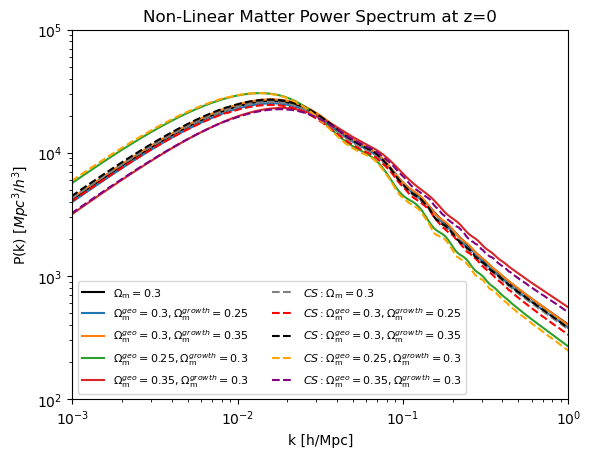

<Figure size 640x480 with 0 Axes>

In [ ]:
# This can import the CosmoSIS pickles for the validation

# with open("mps_k_h.pkl", "rb") as in_pkl:
#     k_h = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-03.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_03 = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-025.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_025 = pickle.load(in_pkl)
# with open("mps_om-geo-03-om-growth-035.pkl", "rb") as in_pkl:
#     mps_geo_03_gr_035 = pickle.load(in_pkl)
# with open("mps_om-geo-025-om-growth-03.pkl", "rb") as in_pkl:
#     mps_geo_025_gr_03 = pickle.load(in_pkl)
# with open("mps_om-geo-035-om-growth-03.pkl", "rb") as in_pkl:
#     mps_geo_035_gr_03 = pickle.load(in_pkl)

plt.loglog(ks / h, nonlinear_pk_3_3[0, :] * h ** 3, color="black",
           label="$\\Omega_{\\rm m}=0.3$")
plt.loglog(ks / h, nonlinear_pk_3_25[0, :] * h ** 3,
           label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$")
plt.loglog(ks / h, nonlinear_pk_3_35[0, :] * h ** 3,
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$")
plt.loglog(ks / h, nonlinear_pk_25_3[0, :] * h ** 3,
    label="$\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.3$")
plt.loglog(ks / h, nonlinear_pk_35_3[0, :] * h ** 3,
    label="$\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.3$")

# plt.plot(k_h, mps_geo_03_gr_03[0, :], label="$CS:\\Omega_{\\rm m}=0.3$",
#         color="grey", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_025[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3,\\Omega^{growth}_{\\rm m}=0.25$",
#         color="red", linestyle='--')
# plt.plot(k_h, mps_geo_03_gr_035[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3,\\Omega^{growth}_{\\rm m}=0.35$",
#         color="black", linestyle='--')
# plt.plot(k_h, mps_geo_025_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.25,\\Omega^{growth}_{\\rm m}=0.3$",
#         color="orange", linestyle='--')
# plt.plot(k_h, mps_geo_035_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.35,\\Omega^{growth}_{\\rm m}=0.3$",
#         color="purple", linestyle='--')

plt.xlabel("k [h/Mpc]")
plt.ylabel(r"P(k) [$Mpc^3/h^3$]")
plt.xlim(1e-3, 1e0)
plt.ylim(1e2, 1e5)
plt.title("Non-Linear Matter Power Spectrum at z=0")
plt.legend(ncol=2, fontsize=8)
plt.savefig("nl_power_spectra.png", dpi=300)
plt.show()
plt.clf()

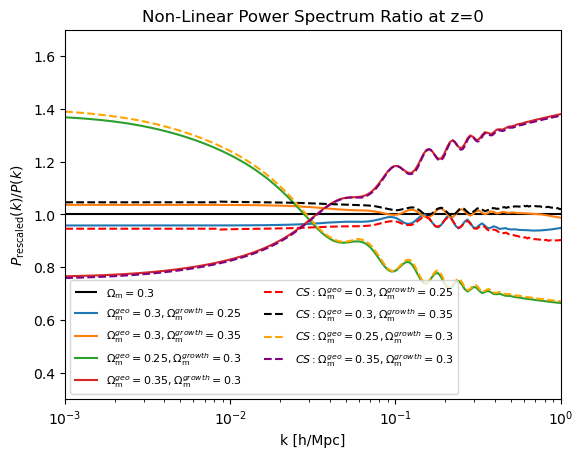

<Figure size 640x480 with 0 Axes>

In [ ]:
# Plot the ratio of the rescaled and the standard MPS

plt.hlines(1, np.min(ks), np.max(ks), label="$\\Omega_{\\rm m}=0.3$",
           color="black")
plt.plot(ks / h, nonlinear_pk_3_25[0, :] / nonlinear_pk_3_3[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$")
plt.plot(ks / h, nonlinear_pk_3_35[0, :] / nonlinear_pk_3_3[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$")
plt.plot(ks / h, nonlinear_pk_25_3[0, :] / nonlinear_pk_3_3[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.3$")
plt.plot(ks / h, nonlinear_pk_35_3[0, :] / nonlinear_pk_3_3[0, :],
    label="$\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.3$")

# plt.plot(k_h, mps_geo_03_gr_025[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.25$",
#         color="red",
#         linestyle='--'
#         )
# plt.plot(k_h, mps_geo_03_gr_035[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.3, \\Omega^{growth}_{\\rm m}=0.35$",
#         color="black",
#         linestyle='--'
#         )
# plt.plot(k_h, mps_geo_025_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.25, \\Omega^{growth}_{\\rm m}=0.3$",
#         color="orange",
#         linestyle='--'
#         )
# plt.plot(k_h, mps_geo_035_gr_03[0, :] / mps_geo_03_gr_03[0, :],
#         label="$CS:\\Omega^{geo}_{\\rm m}=0.35, \\Omega^{growth}_{\\rm m}=0.3$",
#         color="purple",
#         linestyle='--',
#         )

plt.title("Non-Linear Power Spectrum Ratio at z=0")
plt.xlabel("k [h/Mpc]")
plt.ylabel("$P_{\\rm rescaled}(k)/P(k)$")
plt.xscale("log")
plt.xlim(1e-3, 1e0)
plt.ylim(0.3, 1.7)
plt.legend(ncol=2, fontsize=8)
plt.savefig("nl_power_spectra_ratio.png", dpi=300)
plt.show()
plt.clf()